In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import wandb
DOWNLOAD=False
import plotly.io as pio
pio.templates.default = "plotly_white"

In [2]:
if DOWNLOAD:
    api = wandb.Api(timeout=30)
    runs = api.runs("eth-ticinesi/cramming-pretrain",
                    filters={"tags": {"$in": ["new-paper"]}})
    
    r_acc = []
    for r in runs:
        print(r.name)
        if r.name == "opt-350m" or "llama-standard":
            keys = ["validation_loss"]
        else:
            keys = ["loss", "validation_loss", "tokens"]
        tmp = r.scan_history(keys=keys)

        acc = []
        for i,t in enumerate(tmp):
            d = pd.DataFrame(t, index=[0])
            acc.append(d)
            
        df = pd.concat(acc)
        r_acc.append(df)

In [3]:
#--------------RUN THIS IF DOWNLOAD--------------------
if DOWNLOAD:
    runs = {}
    runs['Baseline-24'] = pd.concat([r_acc[5], r_acc[8]])
    runs['GPTHF-16-8'] = pd.concat([r_acc[6], r_acc[9]])
    runs['Baseline-12'] = r_acc[0]
    runs['GPTHF-8-4'] = r_acc[1]
    runs['LLaMA-12'] = r_acc[3]
    runs['LLaMA-24'] = r_acc[7]
    runs['OPT-125M'] = r_acc[4]
    runs['OPT-350M'] = r_acc[2]

    # for k in runs:       # I messed up sometimes the boundaries and the correct values should be the later runs
    #     runs[k] = runs[k].drop_duplicates(subset=['tokens'], keep='last')
    combined_df = pd.DataFrame()

    for key, df in runs.items():
        df_copy = df.copy() 
        df_copy['source'] = key  
        combined_df = pd.concat([combined_df, df_copy], ignore_index=True)

    combined_df.drop(combined_df.index[[7,18]], inplace=True)
    combined_df.reset_index(drop=True, inplace=True)
    combined_df['tokens'] = ((combined_df.index % 10) + 1) * 1e9

    combined_df.to_csv("combined_df.csv", index=False)

In [4]:
#-------------IF STORED IN DISK------------------
df = pd.read_csv('combined_df.csv')
runs = {}
for key, df in df.groupby('source'):
    runs[key] = df

In [8]:
runs

{'Baseline-12':     validation_loss       source        tokens
 20         3.322437  Baseline-12  1.000000e+09
 21         3.147040  Baseline-12  2.000000e+09
 22         3.046786  Baseline-12  3.000000e+09
 23         2.994160  Baseline-12  4.000000e+09
 24         2.958241  Baseline-12  5.000000e+09
 25         2.924573  Baseline-12  6.000000e+09
 26         2.920745  Baseline-12  7.000000e+09
 27         2.885463  Baseline-12  8.000000e+09
 28         2.865528  Baseline-12  9.000000e+09
 29         2.867434  Baseline-12  1.000000e+10,
 'Baseline-24':    validation_loss       source        tokens
 0         3.183951  Baseline-24  1.000000e+09
 1         3.003572  Baseline-24  2.000000e+09
 2         2.942127  Baseline-24  3.000000e+09
 3         2.848651  Baseline-24  4.000000e+09
 4         2.816536  Baseline-24  5.000000e+09
 5         2.795497  Baseline-24  6.000000e+09
 6         2.752382  Baseline-24  7.000000e+09
 7         2.765428  Baseline-24  8.000000e+09
 8         2.77683

In [12]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

fig = go.Figure()
marker_symbols = [
    "circle",
    "square",
    "diamond",
    "cross",
    "x",
    "star",
    "hexagon",
    "pentagon",
    "hexagram",
    "star-diamond",
    "star-square",
    "star-triangle-down",
    "star-square-open",
    "star-diamond-open",
    "star-triangle-up-open",
    "star-triangle-down-open",
    "star-square-open",
    "star-diamond-open",
    "star-triangle-up-open",
    "star-triangle-down-open",
]
for i, key in enumerate(runs):
    # Apply exponential transformation
    perplexities = np.exp(runs[key]["validation_loss"])
    if key in ['Baseline-12', 'Baseline-24', 'GPTHF-8-4', 'GPTHF-16-8']:
        fig.add_trace(go.Scatter(
            x=runs[key]["tokens"], 
            y=np.exp(runs[key]["validation_loss"]), 
            mode='lines+markers',
            marker=dict(symbol=marker_symbols[i], size=8),
            name=key,
            # line=dict(width=2)  # **Change this width to reduce line size in legend**
        ))

fig.update_yaxes(title="Perplexity", range=[14, 40], dtick=10, tickvals=[15, 20, 25, 30, 35, 40])
fig.update_xaxes(title="Tokens",
                #  tickvals=[2e9 * i for i in range(1, 6)],
                 range=[0.9e9, 10.2e9])


fig.update_layout(
        legend=dict(orientation="h", yanchor="bottom", y=1, xanchor="center", x=0.5),
        showlegend=True,
    )

fig.update_layout(
        title="",
        font_family="Times New Roman",
        font_size=12,
        title_font_size=12,
        margin_l=0,
        margin_t=0,
        margin_b=5,
        margin_r=0,
        width=550,
        height=300,
    )
fig.show()
# Save to PDF
pio.write_image(fig, f"./validation_perplexities.pdf")


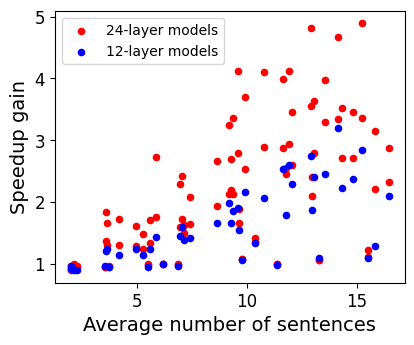

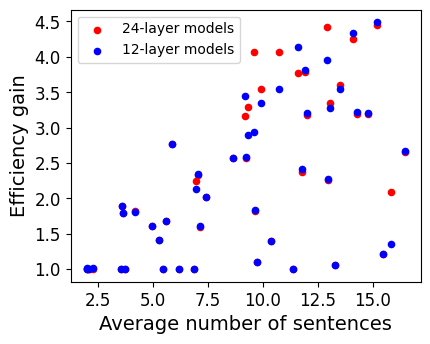

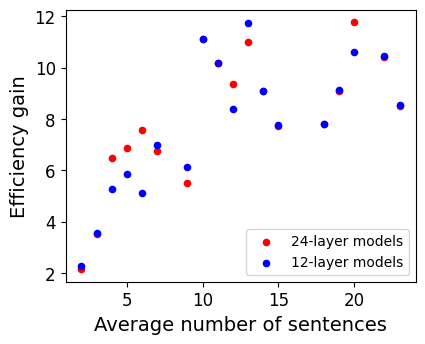

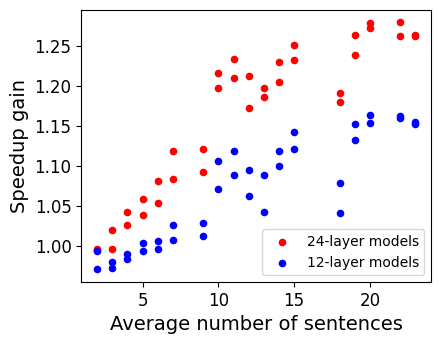

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the dataset
df = pd.read_csv('../cramming/outputs/sentence_vs_time_32.csv')

def process_df(df, col_name, batch_size):
    df[col_name] = df[col_name].apply(lambda x: np.array(x[1:-1].split(',')).astype(float))
    df[col_name] = df[col_name].apply(lambda x: x.mean())

    slow_16_8 = df[df.model == 'gpthf-llama-16-8-slow-new'].set_index('avg_sentences')
    fast_16_8 = df[df.model == 'gpthf-llama-16-8-fast-new'].set_index('avg_sentences')
    speedup_16_8 = slow_16_8[col_name] / fast_16_8[col_name]

    slow_8_4 = df[df.model == 'gpthf-llama-8-4-c512-d1024-48h-slow'].set_index('avg_sentences')
    fast_8_4 = df[df.model == 'gpthf-llama-8-4-c512-d1024-48h-fast'].set_index('avg_sentences')
    speedup_8_4 = slow_8_4[col_name] / fast_8_4[col_name]

    plt.figure(figsize=(5, 4))
    plt.scatter(speedup_16_8.index, speedup_16_8, label='24-layer models', s=20, color='red')
    plt.scatter(speedup_8_4.index, speedup_8_4, label='12-layer models', s=20, color='blue')
    plt.xlabel('Average number of sentences', fontsize=14)  # Increase font size for x-axis label
    if col_name == 'time':
        plt.ylabel('Speedup gain', fontsize=14)
    else:
        plt.ylabel('Efficiency gain', fontsize=14)                # Increase font size for y-axis label
    plt.tick_params(axis='both', which='major', labelsize=12)
    plt.legend()
    plt.subplots_adjust(bottom=0.2)  # Only increase the bottom margin
    plt.subplots_adjust(left=0.2)  # Only increase the left margin
    if col_name == 'time':
        plt.savefig(f'../Paper stuff/speedup_{batch_size}.png')
    else:
        plt.savefig(f'../Paper stuff/efficiency_{batch_size}.png')

process_df(df, 'time', 32)
df1 = pd.read_csv('../cramming/outputs/sentence_vs_flops_32.csv')
df2 = pd.read_csv('../cramming/outputs/sentence_vs_flops_1.csv')
df3 = pd.read_csv('../cramming/outputs/sentence_vs_time_1.csv')
process_df(df1, 'flops', 32)
process_df(df2, 'flops', 1)
process_df(df3, 'time', 1)

In [ ]:
df

,avg_sentences,flops,model
0,2.00000,4.294182e+13,gpthf-llama-16-8-fast-new
1,1.96875,4.268382e+13,gpthf-llama-16-8-fast-new
2,2.09375,4.281281e+13,gpthf-llama-16-8-fast-new
3,2.25000,4.307085e+13,gpthf-llama-16-8-fast-new
4,4.15625,6.159540e+13,gpthf-llama-16-8-fast-new
...,...,...,...
89,14.12500,2.019890e+14,gpthf-llama-16-8-slow-new
90,15.50000,2.607740e+14,gpthf-llama-16-8-slow-new
91,16.46875,2.621435e+14,gpthf-llama-16-8-slow-new
92,14.81250,2.434070e+14,gpthf-llama-16-8-slow-new


In [ ]:
df.model.unique()

array(['gpthf-llama-8-4-c512-d1024-48h-slow',
       'gpthf-llama-8-4-c512-d1024-48h-fast', 'gpthf-llama-16-8-fast-new',
       'gpthf-llama-16-8-slow-new'], dtype=object)

In [ ]:
df.avg_sentences

0       2.00000
1       1.96875
2       2.09375
3       2.25000
4       4.15625
         ...   
277    14.12500
278    15.50000
279    16.46875
280    14.81250
281    14.31250
Name: avg_sentences, Length: 282, dtype: float64